In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex4_oerfm import get_config
from constraints.continuous2d_oe_1_copy import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator import Sample2D
from modules.solution_1 import (
    OddEvenDecompositionConstructor2D_1 as OddEvenDecompositionConstructor2D,
)
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(jnp.array([0.1, 0.5, 0.2]), 3, axis=0)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [7]:
eq_instance.shape, bc_instance.shape

((3, 1024), (1024,))

In [8]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) + source_fn(x, y, -theta))

    def q_asym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) - source_fn(x, y, -theta))

    # 角度积分，算平均源项
    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / (jnp.pi)

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [9]:
sampler = Sample2D(domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [10]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (8192, 1024), bc_right.shape: (8192, 1024), bc_lower.shape: (8192, 1024), bc_upper.shape: (8192, 1024)


In [11]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (25200, 3, 1024)


In [12]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (25200, 3)


In [13]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, bc_lower, bc_upper, eq_int.reshape(-1, num_unknowns)],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta, 0] = bdy_value["f_l"](pts_left[1]).squeeze()
vector_b[2 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta, 0] = (
    bdy_value["f_r"](pts_right[1]).squeeze()
)
vector_b[
    4 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_b"](pts_lower[0]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta : 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_t"](pts_upper[0]).squeeze()
vector_b[4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta :, 0] = (
    rhs_int.reshape(-1)
)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (108368, 1024), Vector b: (108368, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")

Matrix A 内存 846.62 MB
Vector b 内存 0.83 MB
A的稀疏度 = 25.08% (零元素比例)
b的稀疏度 = 0.00% (零元素比例)


In [15]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (1024, 1)


In [16]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(0.0699938109388165, 0.002113359593640084)

In [17]:
# import numpy as np
# from numpy.linalg import cond

# U, svals, Vt = np.linalg.svd(matrix_A, full_matrices=False)

# print("前10个奇异值:", svals[:10])
# print("最小奇异值：", svals[-1])
# print("条件数 κ(A) =", svals[0] / svals[-1])

# # 画奇异值谱（对数刻度）
# plt.figure()
# plt.semilogy(svals, marker="o")
# plt.xlabel("Index")
# plt.ylabel("Singular value (log scale)")
# plt.title("Singular Value Spectrum")
# plt.grid(True, which="both")
# plt.show()

# print(f" Matrix A Condition number: {cond(matrix_A):.6e}")
# print(f" Vector b Condition number: {cond(vector_b):.6e}")

In [18]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [19]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [20]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [21]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (-jnp.pi, jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi / 2

In [22]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [23]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(
    f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}"
)  # f([0. 0. 0.]) = 1.000002714641632

f([0 0 0]) = 1.0015427173063443


In [24]:
# data = np.load(f"../src/data/rte2d_ex4_ref_{kn:.1e}.npz")
# mesh_x, mesh_y = data["mesh_x"], data["mesh_y"]
# f_ex = data["rho"]
# print(
#     f"mesh_x.shape: {mesh_x.shape}, mesh_y.shape: {mesh_y.shape}, f_ex.shape: {f_ex.shape}"
# )

# X, Y = np.meshgrid(mesh_x, mesh_y)
# f_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1),
#                                  Y.reshape(-1, 1)).reshape(X.shape)

In [25]:
mesh_x = jnp.linspace(-1, 1, 65)
mesh_y = jnp.linspace(-1, 1, 65)
X, Y = jnp.meshgrid(mesh_x, mesh_y)
f_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)

In [26]:
f_ex = jnp.exp(-mesh_x[:, None] - mesh_y[None, :])
f_ex.shape

(65, 65)

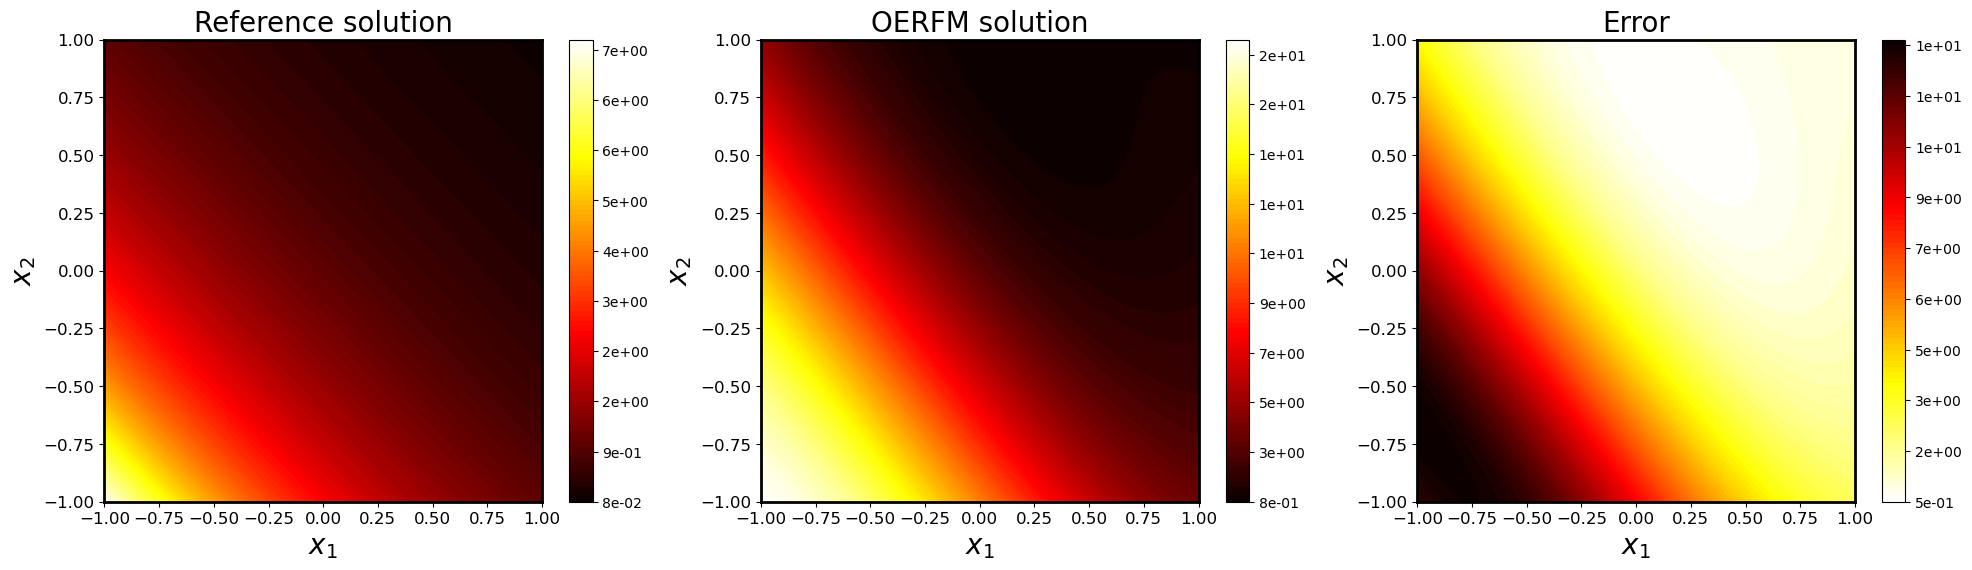

In [27]:
F, F_hat = f_ex, f_approx

font_format = {"size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, Y, F, 100, cmap="hot")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, Y, F_hat, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("OERFM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
# plt.contourf(X, V, np.abs(F - F_hat), 100, cmap='Spectral_r')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)
# plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex4.png", dpi=300)
plt.show()
plt.close()

In [28]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(2.91123946, dtype=float64)

In [29]:
# # 对比同一“速度变量”：参考解和数值解的 -grad rho
# dx = mesh_x[1] - mesh_x[0]
# dy = mesh_y[1] - mesh_y[0]

# # 参考解 rho = F，数值解 rho_hat = F_hat
# dF_dy, dF_dx = np.gradient(F, dy, dx)
# dFh_dy, dFh_dx = np.gradient(F_hat, dy, dx)

# Vx_ref, Vy_ref = -dF_dx, -dF_dy
# Vx_num, Vy_num = -dFh_dx, -dFh_dy

# # 子采样网格
# ny, nx = X.shape
# step_x = max(1, nx // 16)
# step_y = max(1, ny // 16)

# X_s = X[::step_y, ::step_x]
# Y_s = Y[::step_y, ::step_x]
# Vx_ref_s = Vx_ref[::step_y, ::step_x]
# Vy_ref_s = Vy_ref[::step_y, ::step_x]
# Vx_num_s = Vx_num[::step_y, ::step_x]
# Vy_num_s = Vy_num[::step_y, ::step_x]

# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.quiver(X_s, Y_s, Vx_ref_s, Vy_ref_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.title("Reference -grad rho")
# plt.axis("equal")

# plt.subplot(1, 2, 2)
# plt.quiver(X_s, Y_s, Vx_num_s, Vy_num_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.title("OE-APRFM -grad rho_hat")
# plt.axis("equal")

# plt.tight_layout()
# plt.show()

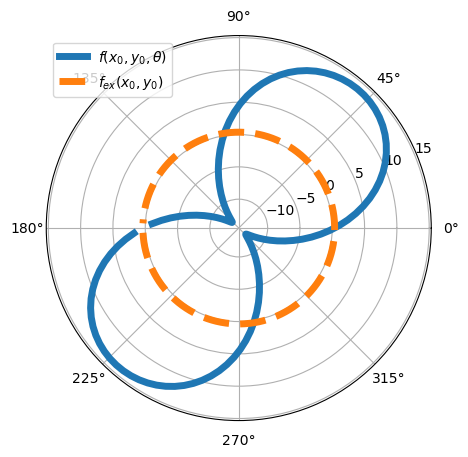

In [30]:
# 画固定点 (x0, y0) 关于 theta 的分布（极坐标图）
x0, y0 = 1.0, 0.0  # 可修改为你关心的点
num_theta = 128
theta_arr = jnp.linspace(-jnp.pi, jnp.pi, num_theta)[1:-1, None]
f_theta = vmap(approx_fn)(
    jnp.full_like(theta_arr, x0), jnp.full_like(theta_arr, y0), theta_arr
)
f_ex_theta = jnp.exp(-x0 - y0) * jnp.ones_like(f_theta)
plt.figure(figsize=(6, 5))
ax = plt.subplot(111, polar=True)
ax.plot(theta_arr.squeeze(), f_theta, linewidth=5, label=r"$f(x_0, y_0, \theta)$")
ax.plot(
    theta_arr.squeeze(),
    f_ex_theta,
    linewidth=5,
    label=r"$f_{ex}(x_0, y_0)$",
    linestyle="--",
)
ax.legend()
plt.show()

In [31]:
err = f_theta - f_ex_theta
err_l2 = jnp.linalg.norm(err) / jnp.linalg.norm(f_ex_theta)
err_l2

Array(26.38895222, dtype=float64)

In [32]:
# # 右边界
# mesh_theta = jnp.linspace(0, jnp.pi, 65)[1:-1]
# X_r, Th = jnp.meshgrid(mesh_x[1:-1], mesh_theta)
# # meshgrid后X_r, Th shape: (65, 65)
# # 需要将输入展平成一维再批量计算，再reshape回来
# X_r_flat = X_r.ravel()
# Th_flat = Th.ravel()

# # 修改：确保参数至少是一维的
# X_r_flat = X_r_flat.reshape(-1, 1)  # shape: (N, 1)
# Th_flat = Th_flat.reshape(-1, 1)  # shape: (N, 1)
# y_flat = -jnp.ones_like(X_r_flat)  # shape: (N, 1)


# def approx_fn_wrapper(x, y, theta):
#     # 确保输入至少是一维的
#     x = jnp.atleast_1d(x)
#     y = jnp.atleast_1d(y)
#     theta = jnp.atleast_1d(theta)
#     return approx_fn(x, y, theta).squeeze()


# # 计算数值解
# f_app_right_flat = vmap(approx_fn_wrapper, (0, 0, 0)
#                         )(X_r_flat, y_flat, Th_flat)
# f_app_right = f_app_right_flat.reshape(X_r.shape)

# # 计算参考解
# f_right = jnp.exp(1 - X_r)
# plt.figure(figsize=(18, 5))
# ax1 = plt.subplot(1, 3, 1)
# c1 = ax1.contourf(X_r, Th, f_app_right, 100, cmap="plasma")
# plt.colorbar(c1, ax=ax1, format="%.0e")
# ax1.set_xlabel(r"$y$")
# ax1.set_ylabel(r"$\theta$")
# ax1.set_title("OE-RFM Right Boundary Solution")
# ax2 = plt.subplot(1, 3, 2)
# c2 = ax2.contourf(X_r, Th, f_right, 100, cmap="plasma")
# plt.colorbar(c2, ax=ax2, format="%.0e")
# ax2.set_xlabel(r"$y$")
# ax2.set_ylabel(r"$\theta$")
# ax2.set_title("Reference Right Boundary Solution")
# ax3 = plt.subplot(1, 3, 3)
# c3 = ax3.contourf(X_r, Th, jnp.abs(f_app_right - f_right), 100, cmap="plasma")
# plt.colorbar(c3, ax=ax3, format="%.0e")
# ax3.set_xlabel(r"$y$")
# ax3.set_ylabel(r"$\theta$")
# ax3.set_title("Error on Right Boundary Solution")
# plt.tight_layout()
# plt.show()